# Laden, Entpacken, Vorverarbeitung

In [1]:
import json
import gzip
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


DATA_PATH = "data/process_data.json"   # oder .json.gz

LENGTH_KEY = "fDrahtlaenge1 (Drehgeber)"
SPEED_KEY  = "fGeschwindigkeit1 (Drehgeber)"
DIAM_KEY   = "fDurchmesser1 (Haerten)"
HARDT_KEY  = "fHaertetemperatur (Haerten)"
TEMPT_KEY  = "fAnlasstemperatur (Anlassen)"
RING_KEY   = "Ring ID"


def load_json_records(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    opener = gzip.open if path.suffix.lower() == ".gz" else open
    mode = "rt"

    # zuerst JSON-Lines versuchen
    records = []
    with opener(path, mode, encoding="utf-8") as f:
        first = f.read(1)
        f.seek(0)

        # JSON-Array
        if first == "[":
            obj = json.load(f)
            if isinstance(obj, list):
                return obj

        # JSON-Lines
        for line in f:
            line = line.strip()
            if not line or line in ("[", "]"):
                continue
            if line.endswith(","):
                line = line[:-1]
            records.append(json.loads(line))
    return records


def unpack_processdata(raw_df):
    rows = []
    for _, row in raw_df.iterrows():
        values = {
            "Time": row["Time"],
            "MachineId": row.get("MachineId"),
            "MachineName": row.get("MachineName"),
            "TimeInterval": row.get("TimeInterval"),
        }
        for item in row.get("ProcessData", []):
            name = item.get("Name") or item.get("name")
            val = item.get("Value") if "Value" in item else item.get("value")
            values[name] = val
        rows.append(values)

    df = pd.DataFrame(rows)

    num_cols = [LENGTH_KEY, SPEED_KEY, DIAM_KEY, HARDT_KEY, TEMPT_KEY, RING_KEY]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
    df = df.sort_values("Time").reset_index(drop=True)

    return df


records = load_json_records(DATA_PATH)
raw_df = pd.DataFrame(records)
df = unpack_processdata(raw_df)

print("RAW shape:", raw_df.shape)
print("UNPACKED shape:", df.shape)
print("UNPACKED columns:")
print(df.columns)

print("\nSampling Check:")
print(df["Time"].diff().value_counts().head())

print("\nStatistische Übersicht:")
print(df[[LENGTH_KEY, SPEED_KEY, DIAM_KEY, HARDT_KEY, TEMPT_KEY, RING_KEY]].describe())

sample_dt_s = df["Time"].diff().dt.total_seconds().dropna().median()
sample_hz = 1.0 / sample_dt_s
print("\nMedian dt [s]:", sample_dt_s)
print("Sampling rate [Hz]:", sample_hz)
print("Mittlere Geschwindigkeit [mm/s]:", df[SPEED_KEY].mean())
print("Mittlere mm pro Sample:", df[SPEED_KEY].mean() * sample_dt_s)

RAW shape: (864000, 5)
UNPACKED shape: (864000, 10)
UNPACKED columns:
Index(['Time', 'MachineId', 'MachineName', 'TimeInterval',
       'fDrahtlaenge1 (Drehgeber)', 'fGeschwindigkeit1 (Drehgeber)',
       'fDurchmesser1 (Haerten)', 'Ring ID', 'fHaertetemperatur (Haerten)',
       'fAnlasstemperatur (Anlassen)'],
      dtype='object')

Sampling Check:
0 days 00:00:00.100000    863999
Name: Time, dtype: int64

Statistische Übersicht:
       fDrahtlaenge1 (Drehgeber)  fGeschwindigkeit1 (Drehgeber)  \
count               8.640000e+05                  864000.000000   
mean                3.579698e+06                      70.600539   
std                 1.760764e+06                       0.998602   
min                 5.297453e+05                      62.000000   
25%                 2.054784e+06                      70.100000   
50%                 3.579945e+06                      70.600000   
75%                 5.104399e+06                      71.200000   
max                 6.629626

# Glättung und Offline-Profilerkennung

In [2]:
from dataclasses import dataclass
from typing import Optional


# leichte robuste Glättung: Median -> Mittelwert
df["diam_med"] = df[DIAM_KEY].rolling(window=5, center=True, min_periods=1).median()
df["diam_smooth"] = df["diam_med"].rolling(window=5, center=True, min_periods=1).mean()


@dataclass
class ProfileFSM:
    low_entry: float = 12.30
    low_exit: float = 12.50
    high_entry: float = 16.50
    high_exit: float = 16.30

    state: str = "LOW"
    low_start_len: Optional[float] = None
    rise_start_len: Optional[float] = None
    plateau_start_len: Optional[float] = None
    fall_start_len: Optional[float] = None

    low_start_ts: Optional[pd.Timestamp] = None
    rise_start_ts: Optional[pd.Timestamp] = None

    low_start_idx: Optional[int] = None
    rise_start_idx: Optional[int] = None

    last_len: Optional[float] = None
    last_ring: Optional[float] = None

    def reset(self, cur_len=None, cur_ts=None, cur_idx=None, ring_id=None):
        self.state = "LOW"
        self.low_start_len = cur_len
        self.rise_start_len = None
        self.plateau_start_len = None
        self.fall_start_len = None

        self.low_start_ts = cur_ts
        self.rise_start_ts = None

        self.low_start_idx = cur_idx
        self.rise_start_idx = None

        self.last_len = cur_len
        self.last_ring = ring_id

    def step(self, idx, ts, length_mm, diameter_smooth, ring_id=None):
        # Reset nur bei rücklaufender Länge
        if self.last_len is not None and length_mm < self.last_len:
            self.reset(cur_len=length_mm, cur_ts=ts, cur_idx=idx, ring_id=ring_id)

        self.last_len = length_mm
        self.last_ring = ring_id

        if self.low_start_len is None:
            self.low_start_len = length_mm
            self.low_start_ts = ts
            self.low_start_idx = idx

        if self.state == "LOW":
            if diameter_smooth > self.low_exit:
                self.rise_start_len = length_mm
                self.rise_start_ts = ts
                self.rise_start_idx = idx
                self.state = "RISE"

        elif self.state == "RISE":
            if diameter_smooth >= self.high_entry:
                self.plateau_start_len = length_mm
                self.state = "HIGH"

        elif self.state == "HIGH":
            if diameter_smooth < self.high_exit:
                self.fall_start_len = length_mm
                self.state = "FALL"

        elif self.state == "FALL":
            if diameter_smooth <= self.low_entry:
                end_len = length_mm
                end_ts = ts
                end_idx = idx

                if None not in (
                    self.low_start_len,
                    self.rise_start_len,
                    self.plateau_start_len,
                    self.fall_start_len,
                    self.low_start_ts,
                    self.low_start_idx,
                    self.rise_start_ts,
                    self.rise_start_idx,
                ):
                    event = {
                        "low_start_mm": float(self.low_start_len),
                        "rise_start_mm": float(self.rise_start_len),
                        "plateau_start_mm": float(self.plateau_start_len),
                        "fall_start_mm": float(self.fall_start_len),
                        "wire_length_end_mm": float(end_len),

                        "ts_start": self.low_start_ts,
                        "ts_end": end_ts,

                        "L2_low_mm": float(self.rise_start_len - self.low_start_len),
                        "L3_rise_mm": float(self.plateau_start_len - self.rise_start_len),
                        "L1_plateau_mm": float(self.fall_start_len - self.plateau_start_len),
                        "L4_fall_mm": float(end_len - self.fall_start_len),

                        "profile_raw_count": int(end_idx - self.low_start_idx + 1),
                        "profile_seconds": float((end_ts - self.low_start_ts).total_seconds()),

                        "bump_raw_count": int(end_idx - self.rise_start_idx + 1),
                        "bump_seconds": float((end_ts - self.rise_start_ts).total_seconds()),
                    }
                else:
                    event = None

                self.reset(cur_len=end_len, cur_ts=end_ts, cur_idx=end_idx, ring_id=ring_id)
                return event

        return None


fsm = ProfileFSM()
profiles = []

for idx, row in df.iterrows():
    ts = row["Time"]
    length_mm = row[LENGTH_KEY]
    diameter_smooth = row["diam_smooth"]
    ring_id = row.get(RING_KEY)

    if pd.isna(ts) or pd.isna(length_mm) or pd.isna(diameter_smooth):
        continue

    if fsm.low_start_len is None:
        fsm.reset(cur_len=float(length_mm), cur_ts=ts, cur_idx=idx, ring_id=ring_id)

    prof = fsm.step(
        idx=idx,
        ts=ts,
        length_mm=float(length_mm),
        diameter_smooth=float(diameter_smooth),
        ring_id=ring_id,
    )
    if prof is not None:
        profiles.append(prof)

profiles_df = pd.DataFrame(profiles)
profiles_df["L_total_mm"] = (
    profiles_df["L1_plateau_mm"]
    + profiles_df["L2_low_mm"]
    + profiles_df["L3_rise_mm"]
    + profiles_df["L4_fall_mm"]
)

print("Anzahl erkannter Profile:", len(profiles_df))
print("\nProfilstatistik:")
print(
    profiles_df[
        ["L1_plateau_mm", "L2_low_mm", "L3_rise_mm", "L4_fall_mm", "L_total_mm", "profile_raw_count", "profile_seconds"]
    ].describe()
)

Anzahl erkannter Profile: 854

Profilstatistik:
       L1_plateau_mm   L2_low_mm   L3_rise_mm  L4_fall_mm   L_total_mm  \
count     854.000000  854.000000   854.000000  854.000000   854.000000   
mean     5722.751923  959.311169   228.555974  229.244548  7139.863614   
std        27.330709   33.576689    37.098343    5.491700    33.613035   
min      5572.686000    0.000000   209.029000  212.922000  6958.620000   
25%      5720.412000  955.324000   223.932250  225.487000  7137.556000   
50%      5724.678000  961.484000   226.013500  229.043500  7141.441500   
75%      5728.695000  962.960500   231.362750  233.122000  7146.591000   
max      5879.849000  994.986000  1300.455000  248.351000  7320.205000   

       profile_raw_count  profile_seconds  
count         854.000000       854.000000  
mean         1012.303279       101.130328  
std             0.947911         0.094791  
min          1010.000000       100.900000  
25%          1012.000000       101.100000  
50%          1012.000

# Erwartungswert und n.i.O.-Rate

In [3]:
min_profiles_eval = 20
tol_mm = 30.0

running_means = {"L1": [], "L2": [], "L3": [], "L4": []}
nio_flags = []

mean_L1 = None
mean_L2 = None
mean_L3 = None
mean_L4 = None

n = 0
for _, row in profiles_df.iterrows():
    if n >= min_profiles_eval:
        dL1 = row["L1_plateau_mm"] - mean_L1
        dL2 = row["L2_low_mm"] - mean_L2
        dL3 = row["L3_rise_mm"] - mean_L3
        dL4 = row["L4_fall_mm"] - mean_L4
        nio = any(abs(x) > tol_mm for x in [dL1, dL2, dL3, dL4])
    else:
        nio = False

    nio_flags.append(nio)

    n += 1
    if mean_L1 is None:
        mean_L1 = row["L1_plateau_mm"]
        mean_L2 = row["L2_low_mm"]
        mean_L3 = row["L3_rise_mm"]
        mean_L4 = row["L4_fall_mm"]
    else:
        mean_L1 += (row["L1_plateau_mm"] - mean_L1) / n
        mean_L2 += (row["L2_low_mm"] - mean_L2) / n
        mean_L3 += (row["L3_rise_mm"] - mean_L3) / n
        mean_L4 += (row["L4_fall_mm"] - mean_L4) / n

profiles_df["nio"] = nio_flags

print("Warm-up-Profile:", min_profiles_eval)
print("n.i.O.-Rate nach Warm-up:", profiles_df.loc[min_profiles_eval:, "nio"].mean())
print("n.i.O.-Anzahl:", int(profiles_df["nio"].sum()))

print("\nMittelwerte L1-L4:")
print(profiles_df[["L1_plateau_mm", "L2_low_mm", "L3_rise_mm", "L4_fall_mm"]].mean())

Warm-up-Profile: 20
n.i.O.-Rate nach Warm-up: 0.09112709832134293
n.i.O.-Anzahl: 76

Mittelwerte L1-L4:
L1_plateau_mm    5722.751923
L2_low_mm         959.311169
L3_rise_mm        228.555974
L4_fall_mm        229.244548
dtype: float64


# Korrelation speed <-> hard_temp mit Lag

Beste Lag-Korrelation:
lag_s           456.500000
pearson_corr     -0.000614
Name: 4565, dtype: float64


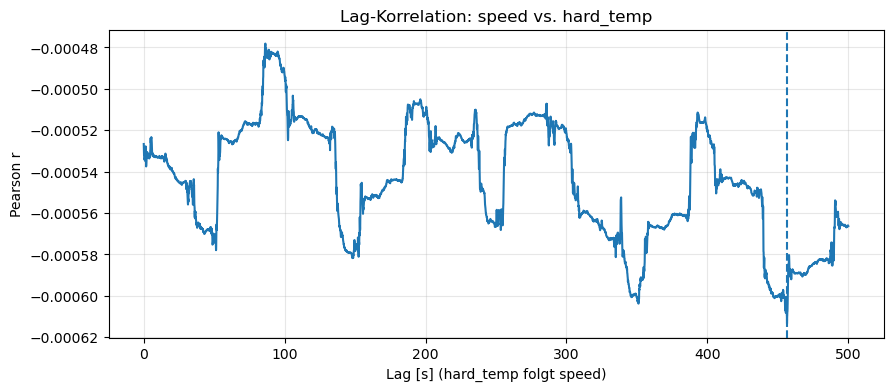

In [56]:
speed = pd.to_numeric(df[SPEED_KEY], errors="coerce")
hard = pd.to_numeric(df[HARDT_KEY], errors="coerce")

valid = speed.notna() & hard.notna()
speed = speed[valid].reset_index(drop=True)
hard = hard[valid].reset_index(drop=True)

max_lag_s = 500
sample_dt_s = float(df["Time"].diff().dt.total_seconds().dropna().median())
max_lag_samples = int(max_lag_s / sample_dt_s)

lags = []
corrs = []

for lag in range(0, max_lag_samples + 1):
    # lag > 0: hard_temp folgt speed
    s1 = speed.iloc[:-lag] if lag > 0 else speed
    h1 = hard.iloc[lag:] if lag > 0 else hard

    if len(s1) < 10:
        continue

    corr = s1.corr(h1)
    lags.append(lag * sample_dt_s)
    corrs.append(corr)

lag_corr_df = pd.DataFrame({"lag_s": lags, "pearson_corr": corrs})
best_row = lag_corr_df.iloc[lag_corr_df["pearson_corr"].abs().idxmax()]

print("Beste Lag-Korrelation:")
print(best_row)

plt.figure(figsize=(10, 4))
plt.plot(lag_corr_df["lag_s"], lag_corr_df["pearson_corr"])
plt.axvline(best_row["lag_s"], linestyle="--")
plt.title("Lag-Korrelation: speed vs. hard_temp")
plt.xlabel("Lag [s] (hard_temp folgt speed)")
plt.ylabel("Pearson r")
plt.grid(True, alpha=0.3)
plt.show()

# Korrelation auf Profilfenstern

Profilfenster-Korrelation:
count    854.000000
mean      -0.000492
std        0.024218
min       -0.070803
25%       -0.017405
50%       -0.000574
75%        0.014452
max        0.081806
Name: corr_speed_hardtemp_profile, dtype: float64


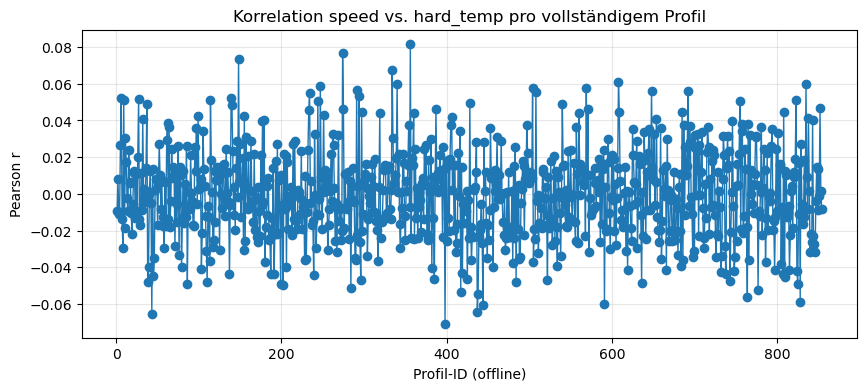

In [5]:
def corr_in_window(window_df):
    s = pd.to_numeric(window_df[SPEED_KEY], errors="coerce")
    h = pd.to_numeric(window_df[HARDT_KEY], errors="coerce")
    valid = s.notna() & h.notna()
    if valid.sum() < 10:
        return np.nan
    return s[valid].corr(h[valid])


profile_corrs = []
length_values = df[LENGTH_KEY].values

for i, p in profiles_df.iterrows():
    start_mm = p["low_start_mm"]
    end_mm = p["wire_length_end_mm"]

    i0 = np.searchsorted(length_values, start_mm, side="left")
    i1 = np.searchsorted(length_values, end_mm, side="right")

    w = df.iloc[i0:i1]
    profile_corrs.append(corr_in_window(w))

profiles_df["corr_speed_hardtemp_profile"] = profile_corrs

print("Profilfenster-Korrelation:")
print(profiles_df["corr_speed_hardtemp_profile"].describe())

plt.figure(figsize=(10, 4))
plt.plot(profiles_df.index + 1, profiles_df["corr_speed_hardtemp_profile"], marker="o", lw=1)
plt.title("Korrelation speed vs. hard_temp pro vollständigem Profil")
plt.xlabel("Profil-ID (offline)")
plt.ylabel("Pearson r")
plt.grid(True, alpha=0.3)
plt.show()

# Temperaturstatistik je Profilphase

In [6]:
phase_rows = []
length_values = df[LENGTH_KEY].values

for i, p in profiles_df.iterrows():
    boundaries = [
        ("L2_low", p["low_start_mm"], p["rise_start_mm"]),
        ("L3_rise", p["rise_start_mm"], p["plateau_start_mm"]),
        ("L1_plateau", p["plateau_start_mm"], p["fall_start_mm"]),
        ("L4_fall", p["fall_start_mm"], p["wire_length_end_mm"]),
    ]

    for phase_name, start_mm, end_mm in boundaries:
        i0 = np.searchsorted(length_values, start_mm, side="left")
        i1 = np.searchsorted(length_values, end_mm, side="right")
        seg = df.iloc[i0:i1]

        phase_rows.append({
            "profile_id": i + 1,
            "phase": phase_name,
            "n_samples": len(seg),
            "hard_temp_mean": pd.to_numeric(seg[HARDT_KEY], errors="coerce").mean(),
            "hard_temp_std": pd.to_numeric(seg[HARDT_KEY], errors="coerce").std(),
            "temp_temp_mean": pd.to_numeric(seg[TEMPT_KEY], errors="coerce").mean(),
            "temp_temp_std": pd.to_numeric(seg[TEMPT_KEY], errors="coerce").std(),
            "speed_mean": pd.to_numeric(seg[SPEED_KEY], errors="coerce").mean(),
        })

phase_df = pd.DataFrame(phase_rows)

print("Phasenstatistik – Mittelwerte über alle Profile:")
print(
    phase_df.groupby("phase")[["n_samples", "hard_temp_mean", "hard_temp_std", "temp_temp_mean", "temp_temp_std", "speed_mean"]]
    .mean()
    .sort_index()
)

Phasenstatistik – Mittelwerte über alle Profile:
             n_samples  hard_temp_mean  hard_temp_std  temp_temp_mean  \
phase                                                                   
L1_plateau  810.522248      989.061265       6.058983      456.030755   
L2_low      137.667447      989.107863       0.910667      455.279352   
L3_rise      33.606557      988.956975       0.648493      456.096723   
L4_fall      33.507026      990.523626       0.754085      454.706212   

            temp_temp_std  speed_mean  
phase                                  
L1_plateau       2.453512   70.692104  
L2_low           0.567502   70.203426  
L3_rise          0.281320   70.106613  
L4_fall          0.230961   70.518419  


# Six Sigma mit 5-Minuten-Fenster

In [7]:
window_s = 5 * 60
window_n = int(window_s / sample_dt_s)

print("5-Minuten-Fenster in Samples:", window_n)

for metric_col in [HARDT_KEY, TEMPT_KEY]:
    s = pd.to_numeric(df[metric_col], errors="coerce")

    # Statistik NUR aus der Vergangenheit
    mu = s.shift(1).rolling(window=window_n, min_periods=window_n).mean()
    sd = s.shift(1).rolling(window=window_n, min_periods=window_n).std()

    lcl = mu - 3.0 * sd
    ucl = mu + 3.0 * sd

    violated = (s < lcl) | (s > ucl)
    violated = violated.fillna(False)

    out = pd.DataFrame({
        "Time": df["Time"],
        "value": s,
        "mu": mu,
        "sd": sd,
        "lcl": lcl,
        "ucl": ucl,
        "violated": violated,
    })

    warmup_mask = out["mu"].isna()
    stable_mask = ~warmup_mask

    print("\nMetric:", metric_col)
    print("Warm-up Samples:", int(warmup_mask.sum()))
    print("Stable Samples:", int(stable_mask.sum()))
    print("Violations nach Warm-up:", int(out.loc[stable_mask, "violated"].sum()))
    print("Violation Rate nach Warm-up:", float(out.loc[stable_mask, "violated"].mean()))

    first_events = out.loc[stable_mask & out["violated"], ["Time", "value", "mu", "sd", "lcl", "ucl"]].head(10)
    print("\nErste Violations:")
    print(first_events)

5-Minuten-Fenster in Samples: 3000

Metric: fHaertetemperatur (Haerten)
Warm-up Samples: 3000
Stable Samples: 861000
Violations nach Warm-up: 35166
Violation Rate nach Warm-up: 0.04084320557491289

Erste Violations:
                        Time     value          mu        sd         lcl  \
3381 2026-03-01 08:05:38.100  1005.592  988.862742  5.288451  972.997389   
3382 2026-03-01 08:05:38.200  1006.581  988.867629  5.297130  972.976240   
3383 2026-03-01 08:05:38.300  1007.895  988.872584  5.306739  972.952368   
3384 2026-03-01 08:05:38.400  1008.363  988.877927  5.317811  972.924493   
3385 2026-03-01 08:05:38.500  1007.915  988.883215  5.329289  972.895349   
3386 2026-03-01 08:05:38.600  1008.335  988.888279  5.340145  972.867844   
3387 2026-03-01 08:05:38.700  1008.850  988.893719  5.351631  972.838825   
3388 2026-03-01 08:05:38.800  1009.214  988.899388  5.363751  972.808135   
3389 2026-03-01 08:05:38.900  1008.979  988.904977  5.376170  972.776467   
3390 2026-03-01 08:05:39

#### Erkentnisse: 

Mit dem einfachen globalen 5-Minuten-Fenster:

Härtetemperatur: ca. 4.08 % Verletzungen

Anlasstemperatur: ca. 2.03 % Verletzungen

--> Zu viele Alarme

Visualisierung einzelner Offline-Profile

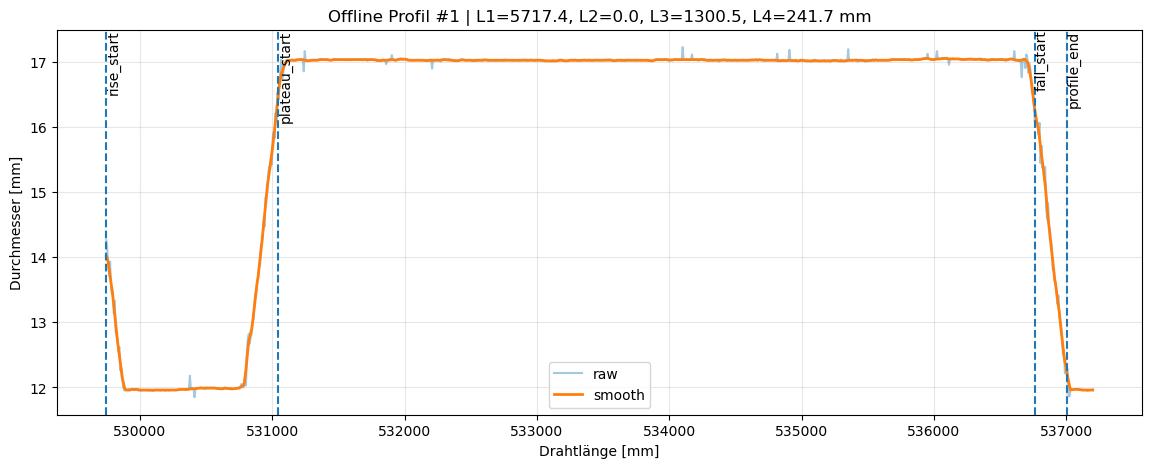

In [10]:
def plot_profile_example(profile_idx=10):
    p = profiles_df.iloc[profile_idx]

    start_mm = p["low_start_mm"] - 200
    end_mm = p["wire_length_end_mm"] + 200

    mask = (df[LENGTH_KEY] >= start_mm) & (df[LENGTH_KEY] <= end_mm)
    w = df.loc[mask].copy()

    plt.figure(figsize=(14, 5))
    plt.plot(w[LENGTH_KEY], w[DIAM_KEY], alpha=0.4, label="raw")
    plt.plot(w[LENGTH_KEY], w["diam_smooth"], lw=2, label="smooth")

    for x, name in [
        (p["rise_start_mm"], "rise_start"),
        (p["plateau_start_mm"], "plateau_start"),
        (p["fall_start_mm"], "fall_start"),
        (p["wire_length_end_mm"], "profile_end"),
    ]:
        plt.axvline(x, linestyle="--")
        plt.text(x, plt.ylim()[1], name, rotation=90, va="top")

    plt.title(
        "Offline Profil #{0} | L1={1:.1f}, L2={2:.1f}, L3={3:.1f}, L4={4:.1f} mm".format(
            profile_idx + 1,
            p["L1_plateau_mm"],
            p["L2_low_mm"],
            p["L3_rise_mm"],
            p["L4_fall_mm"],
        )
    )
    plt.xlabel("Drahtlänge [mm]")
    plt.ylabel("Durchmesser [mm]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_profile_example(0)

## Robustere Profilerkennung

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LENGTH_KEY = "fDrahtlaenge1 (Drehgeber)"
SPEED_KEY  = "fGeschwindigkeit1 (Drehgeber)"
DIAM_KEY   = "fDurchmesser1 (Haerten)"
HARDT_KEY  = "fHaertetemperatur (Haerten)"
TEMPT_KEY  = "fAnlasstemperatur (Anlassen)"
RING_KEY   = "Ring ID"

# robuste leichte Glättung
df["diam_med"] = df[DIAM_KEY].rolling(window=5, center=True, min_periods=1).median()
df["diam_smooth"] = df["diam_med"].rolling(window=5, center=True, min_periods=1).mean()

# optionale Steigung des geglätteten Signals
df["diam_slope"] = df["diam_smooth"].diff().fillna(0.0)



In [12]:
from dataclasses import dataclass
from typing import Optional


@dataclass
class ProfileFSMRobust:
    low_entry: float = 12.30
    low_exit: float = 12.50
    high_entry: float = 16.50
    high_exit: float = 16.30

    min_low_samples: int = 20          # 2 s bei 10 Hz
    min_rise_positive_slope: int = 3   # einfache Zusatzabsicherung

    state: str = "UNSYNCED"

    low_count: int = 0
    pos_slope_count: int = 0

    low_candidate_start_len: Optional[float] = None
    low_candidate_start_ts: Optional[pd.Timestamp] = None
    low_candidate_start_idx: Optional[int] = None

    low_start_len: Optional[float] = None
    rise_start_len: Optional[float] = None
    plateau_start_len: Optional[float] = None
    fall_start_len: Optional[float] = None

    low_start_ts: Optional[pd.Timestamp] = None
    rise_start_ts: Optional[pd.Timestamp] = None

    low_start_idx: Optional[int] = None
    rise_start_idx: Optional[int] = None

    last_len: Optional[float] = None

    def _clear_profile_markers(self):
        self.low_start_len = None
        self.rise_start_len = None
        self.plateau_start_len = None
        self.fall_start_len = None

        self.low_start_ts = None
        self.rise_start_ts = None

        self.low_start_idx = None
        self.rise_start_idx = None

    def _enter_unsynced(self):
        self.state = "UNSYNCED"
        self.low_count = 0
        self.pos_slope_count = 0
        self.low_candidate_start_len = None
        self.low_candidate_start_ts = None
        self.low_candidate_start_idx = None
        self._clear_profile_markers()

    def step(
        self,
        idx: int,
        ts: pd.Timestamp,
        length_mm: float,
        diameter_smooth: float,
        slope: float,
    ):
        # Reset bei rücklaufender Länge
        if self.last_len is not None and length_mm < self.last_len:
            self._enter_unsynced()

        self.last_len = length_mm

        # ---------------- UNSYNCED ----------------
        if self.state == "UNSYNCED":
            if diameter_smooth <= self.low_entry:
                if self.low_count == 0:
                    self.low_candidate_start_len = length_mm
                    self.low_candidate_start_ts = ts
                    self.low_candidate_start_idx = idx
                self.low_count += 1

                if self.low_count >= self.min_low_samples:
                    self.state = "LOW"
                    self.low_start_len = self.low_candidate_start_len
                    self.low_start_ts = self.low_candidate_start_ts
                    self.low_start_idx = self.low_candidate_start_idx
            else:
                self.low_count = 0
                self.low_candidate_start_len = None
                self.low_candidate_start_ts = None
                self.low_candidate_start_idx = None

            return None

        # ---------------- LOW ----------------
        if self.state == "LOW":
            if diameter_smooth <= self.low_entry:
                # LOW weiter bestätigen
                return None

            if slope > 0:
                self.pos_slope_count += 1
            else:
                self.pos_slope_count = 0

            if diameter_smooth > self.low_exit and self.pos_slope_count >= self.min_rise_positive_slope:
                self.rise_start_len = length_mm
                self.rise_start_ts = ts
                self.rise_start_idx = idx
                self.state = "RISE"
                self.pos_slope_count = 0

            return None

        # ---------------- RISE ----------------
        if self.state == "RISE":
            if diameter_smooth >= self.high_entry:
                self.plateau_start_len = length_mm
                self.state = "HIGH"
            return None

        # ---------------- HIGH ----------------
        if self.state == "HIGH":
            if diameter_smooth < self.high_exit:
                self.fall_start_len = length_mm
                self.state = "FALL"
            return None

        # ---------------- FALL ----------------
        if self.state == "FALL":
            if diameter_smooth <= self.low_entry:
                end_len = length_mm
                end_ts = ts
                end_idx = idx

                event = None
                if None not in (
                    self.low_start_len,
                    self.rise_start_len,
                    self.plateau_start_len,
                    self.fall_start_len,
                    self.low_start_ts,
                    self.rise_start_ts,
                    self.low_start_idx,
                    self.rise_start_idx,
                ):
                    event = {
                        "low_start_mm": float(self.low_start_len),
                        "rise_start_mm": float(self.rise_start_len),
                        "plateau_start_mm": float(self.plateau_start_len),
                        "fall_start_mm": float(self.fall_start_len),
                        "wire_length_end_mm": float(end_len),

                        "ts_start": self.low_start_ts,
                        "ts_end": end_ts,

                        "L2_low_mm": float(self.rise_start_len - self.low_start_len),
                        "L3_rise_mm": float(self.plateau_start_len - self.rise_start_len),
                        "L1_plateau_mm": float(self.fall_start_len - self.plateau_start_len),
                        "L4_fall_mm": float(end_len - self.fall_start_len),

                        "profile_raw_count": int(end_idx - self.low_start_idx + 1),
                        "profile_seconds": float((end_ts - self.low_start_ts).total_seconds()),

                        "bump_raw_count": int(end_idx - self.rise_start_idx + 1),
                        "bump_seconds": float((end_ts - self.rise_start_ts).total_seconds()),
                    }

                # Nach Profilende nicht direkt LOW bleiben,
                # sondern erneut synchronisieren
                self.state = "UNSYNCED"
                self.low_count = 1
                self.pos_slope_count = 0
                self.low_candidate_start_len = end_len
                self.low_candidate_start_ts = end_ts
                self.low_candidate_start_idx = end_idx
                self._clear_profile_markers()

                return event

            return None

        return None

In [13]:
fsm = ProfileFSMRobust(
    low_entry=12.30,
    low_exit=12.50,
    high_entry=16.50,
    high_exit=16.30,
    min_low_samples=20,
    min_rise_positive_slope=3,
)

profiles_robust = []

for idx, row in df.iterrows():
    ts = row["Time"]
    length_mm = row[LENGTH_KEY]
    diameter_smooth = row["diam_smooth"]
    slope = row["diam_slope"]

    if pd.isna(ts) or pd.isna(length_mm) or pd.isna(diameter_smooth):
        continue

    prof = fsm.step(
        idx=idx,
        ts=ts,
        length_mm=float(length_mm),
        diameter_smooth=float(diameter_smooth),
        slope=float(slope),
    )
    if prof is not None:
        profiles_robust.append(prof)

profiles_robust_df = pd.DataFrame(profiles_robust)

if not profiles_robust_df.empty:
    profiles_robust_df["L_total_mm"] = (
        profiles_robust_df["L1_plateau_mm"]
        + profiles_robust_df["L2_low_mm"]
        + profiles_robust_df["L3_rise_mm"]
        + profiles_robust_df["L4_fall_mm"]
    )

print("Anzahl erkannter Profile (robust):", len(profiles_robust_df))
print(
    profiles_robust_df[
        ["L1_plateau_mm", "L2_low_mm", "L3_rise_mm", "L4_fall_mm", "L_total_mm", "profile_raw_count", "profile_seconds"]
    ].describe()
)

Anzahl erkannter Profile (robust): 854
       L1_plateau_mm   L2_low_mm  L3_rise_mm  L4_fall_mm   L_total_mm  \
count     854.000000  854.000000  854.000000  854.000000   854.000000   
mean     5722.751923  962.188872  225.546494  229.244548  7139.731837   
std        27.330709    6.923268    5.347874    5.491700    33.362880   
min      5572.686000  930.509000  209.029000  212.922000  6958.620000   
25%      5720.412000  960.345500  223.193250  225.487000  7137.556000   
50%      5724.678000  962.072500  224.918500  229.043500  7141.441500   
75%      5728.695000  967.341250  230.443750  233.122000  7146.591000   
max      5879.849000  994.986000  244.279000  248.351000  7320.205000   

       profile_raw_count  profile_seconds  
count         854.000000       854.000000  
mean         1012.284543       101.128454  
std             0.756260         0.075626  
min          1010.000000       100.900000  
25%          1012.000000       101.100000  
50%          1012.000000       101.1000

In [20]:
def is_plausible_profile(row):
    L1 = row["L1_plateau_mm"]
    L2 = row["L2_low_mm"]
    L3 = row["L3_rise_mm"]
    L4 = row["L4_fall_mm"]
    L_total = row["L_total_mm"]

    return (
        5600 <= L1 <= 5850 and
        850 <= L2 <= 1050 and
        150 <= L3 <= 350 and
        180 <= L4 <= 280 and
        7000 <= L_total <= 7250 and
        1000 <= row["profile_raw_count"] <= 1025 and
        100.0 <= row["profile_seconds"] <= 102.5
    )

profiles_robust_df["plausible"] = profiles_robust_df.apply(is_plausible_profile, axis=1)

profiles_valid_df = profiles_robust_df.loc[profiles_robust_df["plausible"]].copy()
profiles_invalid_df = profiles_robust_df.loc[~profiles_robust_df["plausible"]].copy()

print("Plausible Profile:", len(profiles_valid_df))
print("Unplausible Profile:", len(profiles_invalid_df))

print("\nStatistik plausible Profile:")
print(
    profiles_valid_df[
        ["L1_plateau_mm", "L2_low_mm", "L3_rise_mm", "L4_fall_mm", "L_total_mm", "profile_raw_count", "profile_seconds"]
    ].describe()
)

Plausible Profile: 828
Unplausible Profile: 26

Statistik plausible Profile:
       L1_plateau_mm   L2_low_mm  L3_rise_mm  L4_fall_mm   L_total_mm  \
count     828.000000  828.000000  828.000000  828.000000   828.000000   
mean     5723.163528  962.253752  225.577781  229.273798  7140.268860   
std        16.002866    5.826518    5.243224    5.441879    18.867879   
min      5608.824000  942.570000  209.029000  212.922000  7002.138000   
25%      5720.550750  960.543500  223.291500  225.504250  7137.671750   
50%      5724.700500  962.073500  224.927500  229.118500  7141.459000   
75%      5728.586750  967.133000  230.455250  233.106250  7146.506250   
max      5821.141000  984.666000  240.767000  248.351000  7247.264000   

       profile_raw_count  profile_seconds  
count         828.000000       828.000000  
mean         1012.288647       101.128865  
std             0.758677         0.075868  
min          1010.000000       100.900000  
25%          1012.000000       101.100000  
5

In [21]:
def plot_profile_from_row(profile_row, title_prefix="Offline Profil"):
    start_mm = profile_row["low_start_mm"] - 200
    end_mm = profile_row["wire_length_end_mm"] + 200

    mask = (df[LENGTH_KEY] >= start_mm) & (df[LENGTH_KEY] <= end_mm)
    w = df.loc[mask].copy()

    plt.figure(figsize=(14, 5))
    plt.plot(w[LENGTH_KEY], w[DIAM_KEY], alpha=0.4, label="raw")
    plt.plot(w[LENGTH_KEY], w["diam_smooth"], lw=2, label="smooth")

    for x, name in [
        (profile_row["rise_start_mm"], "rise_start"),
        (profile_row["plateau_start_mm"], "plateau_start"),
        (profile_row["fall_start_mm"], "fall_start"),
        (profile_row["wire_length_end_mm"], "profile_end"),
    ]:
        plt.axvline(x, linestyle="--")
        plt.text(x, plt.ylim()[1], name, rotation=90, va="top")

    plt.title(
        f"{title_prefix} | "
        f"L1={profile_row['L1_plateau_mm']:.1f}, "
        f"L2={profile_row['L2_low_mm']:.1f}, "
        f"L3={profile_row['L3_rise_mm']:.1f}, "
        f"L4={profile_row['L4_fall_mm']:.1f} mm"
    )
    plt.xlabel("Drahtlänge [mm]")
    plt.ylabel("Durchmesser [mm]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

     L1_plateau_mm  L2_low_mm  L3_rise_mm  L4_fall_mm  L_total_mm  \
90        5827.789    978.417     228.391     226.601    7261.198   
105       5834.606    974.832     244.279     229.052    7282.769   
111       5589.620    946.755     219.084     221.923    6977.382   
122       5592.646    939.105     210.583     235.026    6977.360   
131       5862.134    984.423     228.620     234.398    7309.575   
133       5585.257    945.592     213.606     228.966    6973.421   
152       5813.639    976.541     234.733     228.052    7252.965   
206       5581.652    945.988     220.054     216.617    6964.311   
216       5860.702    985.977     235.303     227.841    7309.823   
222       5833.531    989.943     228.407     235.228    7287.109   

     profile_raw_count  profile_seconds  
90                1012            101.1  
105               1012            101.1  
111               1012            101.1  
122               1013            101.2  
131               1012        

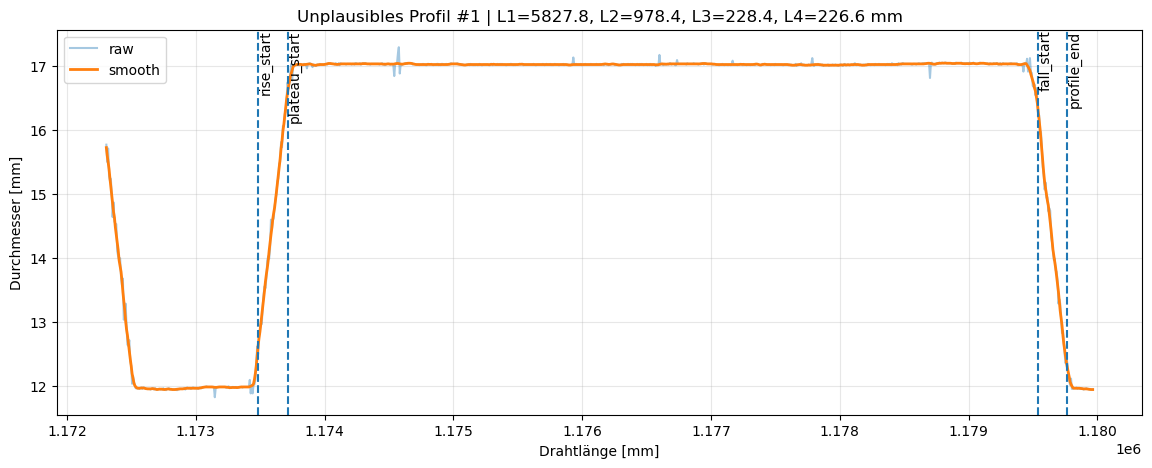

In [22]:
print(profiles_invalid_df.head(10)[
    ["L1_plateau_mm", "L2_low_mm", "L3_rise_mm", "L4_fall_mm", "L_total_mm", "profile_raw_count", "profile_seconds"]
])

if len(profiles_invalid_df) > 0:
    plot_profile_from_row(profiles_invalid_df.iloc[0], title_prefix="Unplausibles Profil #1")

In [25]:
print("Alt erkannt:", len(profiles_df))
print("Neu erkannt:", len(profiles_robust_df))
print("Neu plausibel:", len(profiles_valid_df))

print("\nAlt problematische Extremwerte:")
print(profiles_df[["L2_low_mm", "L3_rise_mm"]].describe())

print("\nNeu problematische Extremwerte:")
print(profiles_robust_df[["L2_low_mm", "L3_rise_mm"]].describe())

print("\nNeu plausible Extremwerte:")
print(profiles_valid_df[["L2_low_mm", "L3_rise_mm"]].describe())

Alt erkannt: 854
Neu erkannt: 854
Neu plausibel: 828

Alt problematische Extremwerte:
        L2_low_mm   L3_rise_mm
count  854.000000   854.000000
mean   959.311169   228.555974
std     33.576689    37.098343
min      0.000000   209.029000
25%    955.324000   223.932250
50%    961.484000   226.013500
75%    962.960500   231.362750
max    994.986000  1300.455000

Neu problematische Extremwerte:
        L2_low_mm  L3_rise_mm
count  854.000000  854.000000
mean   962.188872  225.546494
std      6.923268    5.347874
min    930.509000  209.029000
25%    960.345500  223.193250
50%    962.072500  224.918500
75%    967.341250  230.443750
max    994.986000  244.279000

Neu plausible Extremwerte:
        L2_low_mm  L3_rise_mm
count  828.000000  828.000000
mean   962.253752  225.577781
std      5.826518    5.243224
min    942.570000  209.029000
25%    960.543500  223.291500
50%    962.073500  224.927500
75%    967.133000  230.455250
max    984.666000  240.767000


In [26]:
print(
    profiles_robust_df[
        ["L1_plateau_mm", "L2_low_mm", "L3_rise_mm", "L4_fall_mm", "L_total_mm", "profile_raw_count", "profile_seconds"]
    ].describe()
)

print("Plausible Profile:", len(profiles_valid_df))
print("Unplausible Profile:", len(profiles_invalid_df))

print(
    profiles_valid_df[
        ["L1_plateau_mm", "L2_low_mm", "L3_rise_mm", "L4_fall_mm", "L_total_mm", "profile_raw_count", "profile_seconds"]
    ].describe()
)


       L1_plateau_mm   L2_low_mm  L3_rise_mm  L4_fall_mm   L_total_mm  \
count     854.000000  854.000000  854.000000  854.000000   854.000000   
mean     5722.751923  962.188872  225.546494  229.244548  7139.731837   
std        27.330709    6.923268    5.347874    5.491700    33.362880   
min      5572.686000  930.509000  209.029000  212.922000  6958.620000   
25%      5720.412000  960.345500  223.193250  225.487000  7137.556000   
50%      5724.678000  962.072500  224.918500  229.043500  7141.441500   
75%      5728.695000  967.341250  230.443750  233.122000  7146.591000   
max      5879.849000  994.986000  244.279000  248.351000  7320.205000   

       profile_raw_count  profile_seconds  
count         854.000000       854.000000  
mean         1012.284543       101.128454  
std             0.756260         0.075626  
min          1010.000000       100.900000  
25%          1012.000000       101.100000  
50%          1012.000000       101.100000  
75%          1013.000000       101

## n.i.O.-Bewertung

In [27]:
import pandas as pd
import numpy as np

tol_mm = 30.0
min_profiles_eval = 20  # Warm-up wie im Streaming-Service

work = profiles_valid_df.copy().reset_index(drop=True)

mean_L1 = None
mean_L2 = None
mean_L3 = None
mean_L4 = None
n = 0

rows = []

for i, row in work.iterrows():
    cur = {
        "offline_profile_id": i + 1,
        "L1": float(row["L1_plateau_mm"]),
        "L2": float(row["L2_low_mm"]),
        "L3": float(row["L3_rise_mm"]),
        "L4": float(row["L4_fall_mm"]),
    }

    expected = None
    deviations = None
    nio = False
    violated_dims = []

    # erst prüfen, dann updaten
    if n >= min_profiles_eval:
        expected = {
            "L1": mean_L1,
            "L2": mean_L2,
            "L3": mean_L3,
            "L4": mean_L4,
        }

        deviations = {
            "dL1": cur["L1"] - expected["L1"],
            "dL2": cur["L2"] - expected["L2"],
            "dL3": cur["L3"] - expected["L3"],
            "dL4": cur["L4"] - expected["L4"],
        }

        if abs(deviations["dL1"]) > tol_mm:
            violated_dims.append("L1")
        if abs(deviations["dL2"]) > tol_mm:
            violated_dims.append("L2")
        if abs(deviations["dL3"]) > tol_mm:
            violated_dims.append("L3")
        if abs(deviations["dL4"]) > tol_mm:
            violated_dims.append("L4")

        nio = len(violated_dims) > 0

    rows.append({
        "offline_profile_id": cur["offline_profile_id"],
        "L1": cur["L1"],
        "L2": cur["L2"],
        "L3": cur["L3"],
        "L4": cur["L4"],
        "expected_L1": None if expected is None else expected["L1"],
        "expected_L2": None if expected is None else expected["L2"],
        "expected_L3": None if expected is None else expected["L3"],
        "expected_L4": None if expected is None else expected["L4"],
        "dL1": None if deviations is None else deviations["dL1"],
        "dL2": None if deviations is None else deviations["dL2"],
        "dL3": None if deviations is None else deviations["dL3"],
        "dL4": None if deviations is None else deviations["dL4"],
        "warmup": n < min_profiles_eval,
        "nio": nio,
        "violated_dims": ",".join(violated_dims),
    })

    # jetzt laufende Mittelwerte aktualisieren
    n += 1
    if mean_L1 is None:
        mean_L1 = cur["L1"]
        mean_L2 = cur["L2"]
        mean_L3 = cur["L3"]
        mean_L4 = cur["L4"]
    else:
        mean_L1 += (cur["L1"] - mean_L1) / n
        mean_L2 += (cur["L2"] - mean_L2) / n
        mean_L3 += (cur["L3"] - mean_L3) / n
        mean_L4 += (cur["L4"] - mean_L4) / n

nio_df = pd.DataFrame(rows)

print("Anzahl Profile gesamt:", len(nio_df))
print("Warm-up-Profile:", int(nio_df["warmup"].sum()))
print("Bewertete Profile:", int((~nio_df["warmup"]).sum()))
print("n.i.O.-Profile:", int(nio_df["nio"].sum()))
print("n.i.O.-Quote:", float(nio_df.loc[~nio_df["warmup"], "nio"].mean()))

Anzahl Profile gesamt: 828
Warm-up-Profile: 20
Bewertete Profile: 808
n.i.O.-Profile: 31
n.i.O.-Quote: 0.038366336633663366


### Welche Länge löst am häufigsten n.i.O. aus?

In [28]:
from collections import Counter

counter = Counter()

for s in nio_df.loc[nio_df["nio"], "violated_dims"]:
    for part in s.split(","):
        if part:
            counter[part] += 1

print("Auslösende Längen:")
print(counter)

Auslösende Längen:
Counter({'L1': 31})


### Überblick über die Abweichungen

In [29]:
print(
    nio_df.loc[~nio_df["warmup"], ["dL1", "dL2", "dL3", "dL4"]]
    .abs()
    .describe()
)

              dL1         dL2         dL3         dL4
count  808.000000  808.000000  808.000000  808.000000
mean     7.232944    4.189255    4.082269    4.594119
std     14.382469    4.083704    3.290576    2.930605
min      0.000448    0.002323    0.003709    0.053034
25%      2.260881    0.627176    1.200641    2.875649
50%      4.144231    1.978221    3.243893    3.794867
75%      6.368932    7.077384    6.512722    4.995441
max    114.460409   22.664887   16.574734   19.162866


### print

In [30]:
cols = [
    "offline_profile_id",
    "L1", "L2", "L3", "L4",
    "expected_L1", "expected_L2", "expected_L3", "expected_L4",
    "dL1", "dL2", "dL3", "dL4",
    "violated_dims",
]

print(nio_df.loc[nio_df["nio"], cols].head(20))

     offline_profile_id        L1       L2       L3       L4  expected_L1  \
61                   62  5678.225  952.165  214.978  223.754  5724.453262   
128                 129  5652.123  958.679  223.445  225.216  5724.335656   
133                 134  5821.141  977.306  221.906  226.911  5723.841571   
134                 135  5676.374  954.630  223.864  228.717  5724.567687   
135                 136  5619.199  945.140  220.829  229.035  5724.210696   
142                 143  5806.672  984.666  219.619  233.827  5723.488754   
171                 172  5805.756  976.387  225.876  232.524  5724.254099   
172                 173  5612.502  945.482  225.612  243.737  5724.727948   
183                 184  5657.750  958.476  214.334  231.399  5723.926077   
209                 210  5654.432  951.504  222.316  236.919  5723.726641   
239                 240  5613.812  943.769  218.636  230.277  5723.318259   
265                 266  5662.226  945.155  228.879  230.083  5723.024045   

### Plot n.i.O Historie

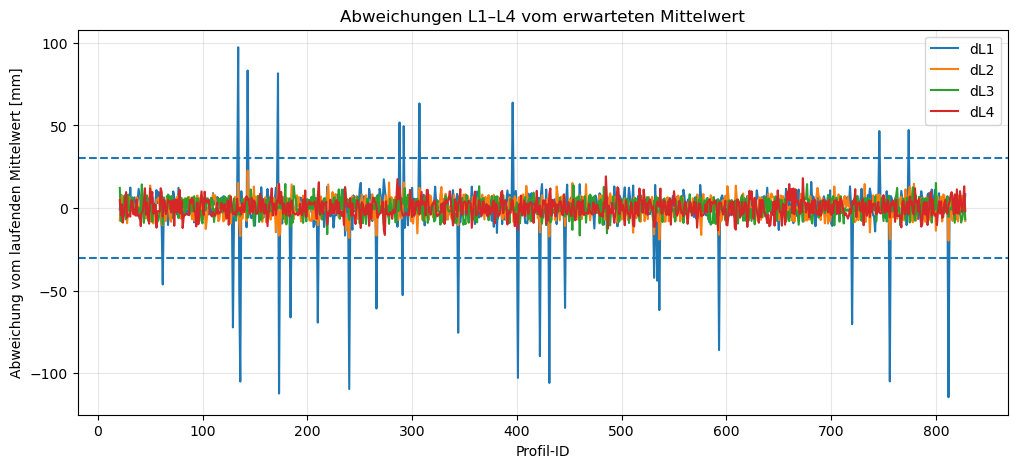

In [31]:
import matplotlib.pyplot as plt

plot_df = nio_df.loc[~nio_df["warmup"]].copy()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["offline_profile_id"], plot_df["dL1"], label="dL1")
plt.plot(plot_df["offline_profile_id"], plot_df["dL2"], label="dL2")
plt.plot(plot_df["offline_profile_id"], plot_df["dL3"], label="dL3")
plt.plot(plot_df["offline_profile_id"], plot_df["dL4"], label="dL4")
plt.axhline(30.0, linestyle="--")
plt.axhline(-30.0, linestyle="--")
plt.xlabel("Profil-ID")
plt.ylabel("Abweichung vom laufenden Mittelwert [mm]")
plt.title("Abweichungen L1–L4 vom erwarteten Mittelwert")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Verbesserte Six Sigma Erkennung

### Rollende Statistik

In [46]:
import pandas as pd
import numpy as np

HARDT_KEY = "fHaertetemperatur (Haerten)"
TEMPT_KEY = "fAnlasstemperatur (Anlassen)"

window_n = 3000   # 5 Minuten bei 10 Hz
persist_n = 30

def prepare_sixsigma_trace_fast(df, metric_col, window_n=3000):
    s = pd.to_numeric(df[metric_col], errors="coerce")

    # Statistik nur aus der Vergangenheit:
    mean = s.shift(1).rolling(window=window_n, min_periods=window_n).mean()
    std = s.shift(1).rolling(window=window_n, min_periods=window_n).std()

    lcl = mean - 3.0 * std
    ucl = mean + 3.0 * std

    violated = ((s < lcl) | (s > ucl)).fillna(False)

    trace = pd.DataFrame({
        "ts": df["Time"],
        "value": s,
        "mean": mean,
        "std": std,
        "lcl": lcl,
        "ucl": ucl,
        "violated": violated,
        "warmup": mean.isna(),
    })

    return trace

### Alarmlogik

In [47]:
def extract_alarm_events_fast(trace_df, persist_n=5):
    violated = trace_df["violated"].to_numpy()
    ts_arr = trace_df["ts"].to_numpy()
    val_arr = trace_df["value"].to_numpy()
    mean_arr = trace_df["mean"].to_numpy()
    std_arr = trace_df["std"].to_numpy()
    lcl_arr = trace_df["lcl"].to_numpy()
    ucl_arr = trace_df["ucl"].to_numpy()

    in_alarm = False
    run_len = 0
    event_rows = []

    for i, is_viol in enumerate(violated):
        if is_viol:
            run_len += 1
        else:
            run_len = 0

        if (not in_alarm) and is_viol and run_len >= persist_n:
            in_alarm = True
            event_rows.append({
                "ts": ts_arr[i],
                "type": "ALARM_START",
                "value": val_arr[i],
                "mean": mean_arr[i],
                "std": std_arr[i],
                "lcl": lcl_arr[i],
                "ucl": ucl_arr[i],
                "violation_run": run_len,
            })

        elif in_alarm and (not is_viol):
            in_alarm = False
            event_rows.append({
                "ts": ts_arr[i],
                "type": "ALARM_END",
                "value": val_arr[i],
                "mean": mean_arr[i],
                "std": std_arr[i],
                "lcl": lcl_arr[i],
                "ucl": ucl_arr[i],
                "violation_run": 0,
            })

    return pd.DataFrame(event_rows)

In [48]:
def build_alarm_episodes(events_df):
    if events_df.empty:
        return pd.DataFrame(columns=["start_ts", "end_ts", "duration_s"])

    episodes = []
    current_start = None

    for _, row in events_df.iterrows():
        if row["type"] == "ALARM_START":
            current_start = row["ts"]
        elif row["type"] == "ALARM_END" and current_start is not None:
            episodes.append({
                "start_ts": current_start,
                "end_ts": row["ts"],
                "duration_s": (row["ts"] - current_start).total_seconds(),
            })
            current_start = None

    return pd.DataFrame(episodes)

In [49]:
hard_trace = prepare_sixsigma_trace_fast(df, HARDT_KEY, window_n=window_n)
temp_trace = prepare_sixsigma_trace_fast(df, TEMPT_KEY, window_n=window_n)

hard_events = extract_alarm_events_fast(hard_trace, persist_n=persist_n)
temp_events = extract_alarm_events_fast(temp_trace, persist_n=persist_n)

hard_episodes = build_alarm_episodes(hard_events)
temp_episodes = build_alarm_episodes(temp_events)

In [50]:
def summarize_alarm_events(name, trace_df, events_df, episodes_df):
    n_start = int((events_df["type"] == "ALARM_START").sum()) if not events_df.empty else 0
    n_end = int((events_df["type"] == "ALARM_END").sum()) if not events_df.empty else 0

    print("\nMetric:", name)
    print("Warm-up Samples:", int(trace_df["warmup"].sum()))
    print("Stable Samples:", int((~trace_df["warmup"]).sum()))
    print("Punktverletzungen nach Warm-up:", int(trace_df.loc[~trace_df["warmup"], "violated"].sum()))
    print("Alarm START Events:", n_start)
    print("Alarm END Events:", n_end)
    print("Alarmepisoden:", len(episodes_df))

    if not episodes_df.empty:
        print("Mittlere Alarmdauer [s]:", float(episodes_df["duration_s"].mean()))
        print("Maximale Alarmdauer [s]:", float(episodes_df["duration_s"].max()))

    if not events_df.empty:
        print("\nErste Events:")
        print(events_df.head(10))


summarize_alarm_events("hard_temp", hard_trace, hard_events, hard_episodes)
summarize_alarm_events("temp_temp", temp_trace, temp_events, temp_episodes)


Metric: hard_temp
Warm-up Samples: 3000
Stable Samples: 861000
Punktverletzungen nach Warm-up: 35166
Alarm START Events: 6
Alarm END Events: 6
Alarmepisoden: 6
Mittlere Alarmdauer [s]: 0.09999999999999999
Maximale Alarmdauer [s]: 0.1

Erste Events:
                       ts         type    value        mean       std  \
0 2026-03-01 08:26:10.800  ALARM_START  972.207  989.305697  5.451660   
1 2026-03-01 08:26:10.900    ALARM_END  973.702  989.299927  5.460590   
2 2026-03-01 20:17:27.000  ALARM_START  972.051  989.108230  5.420536   
3 2026-03-01 20:17:27.100    ALARM_END  974.083  989.102410  5.429469   
4 2026-03-01 21:51:50.200  ALARM_START  973.040  989.426578  5.445692   
5 2026-03-01 21:51:50.300    ALARM_END  974.413  989.421072  5.453903   
6 2026-03-02 05:47:08.400  ALARM_START  972.307  989.325555  5.420583   
7 2026-03-02 05:47:08.500    ALARM_END  974.298  989.319910  5.429481   
8 2026-03-02 07:09:43.700  ALARM_START  973.311  989.696453  5.401093   
9 2026-03-02 07:09:4

### Vergleichsplot mit unterschiedlichen Persistenzen

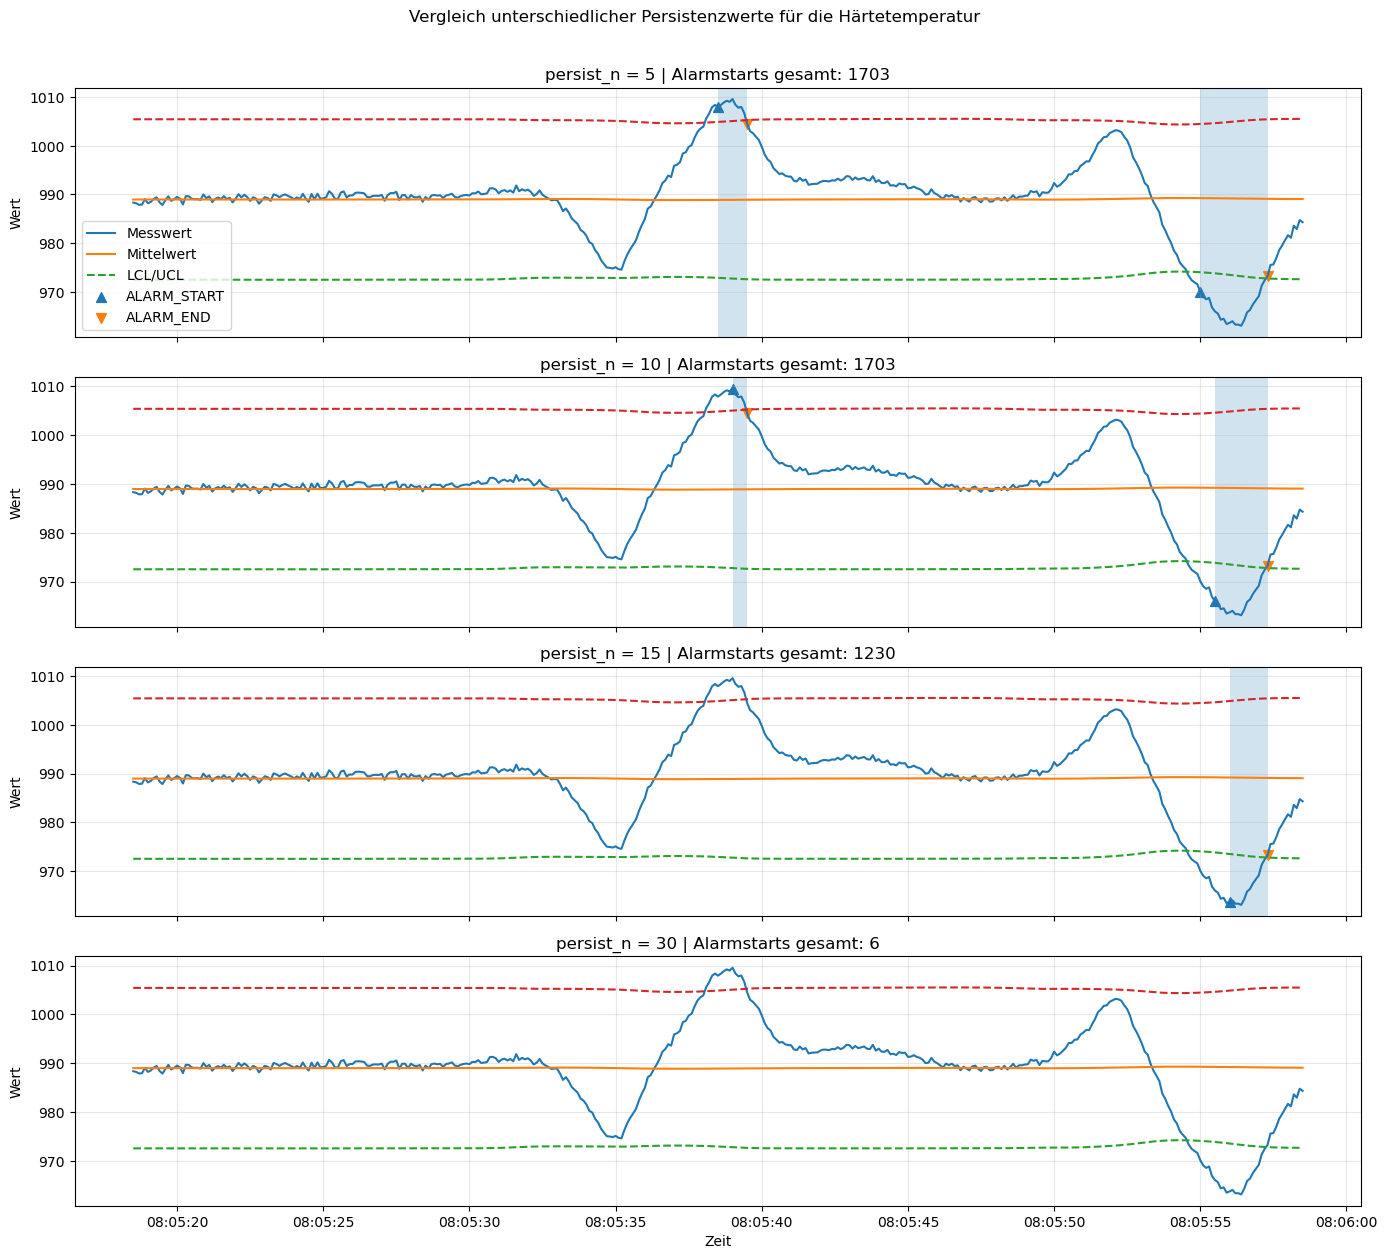

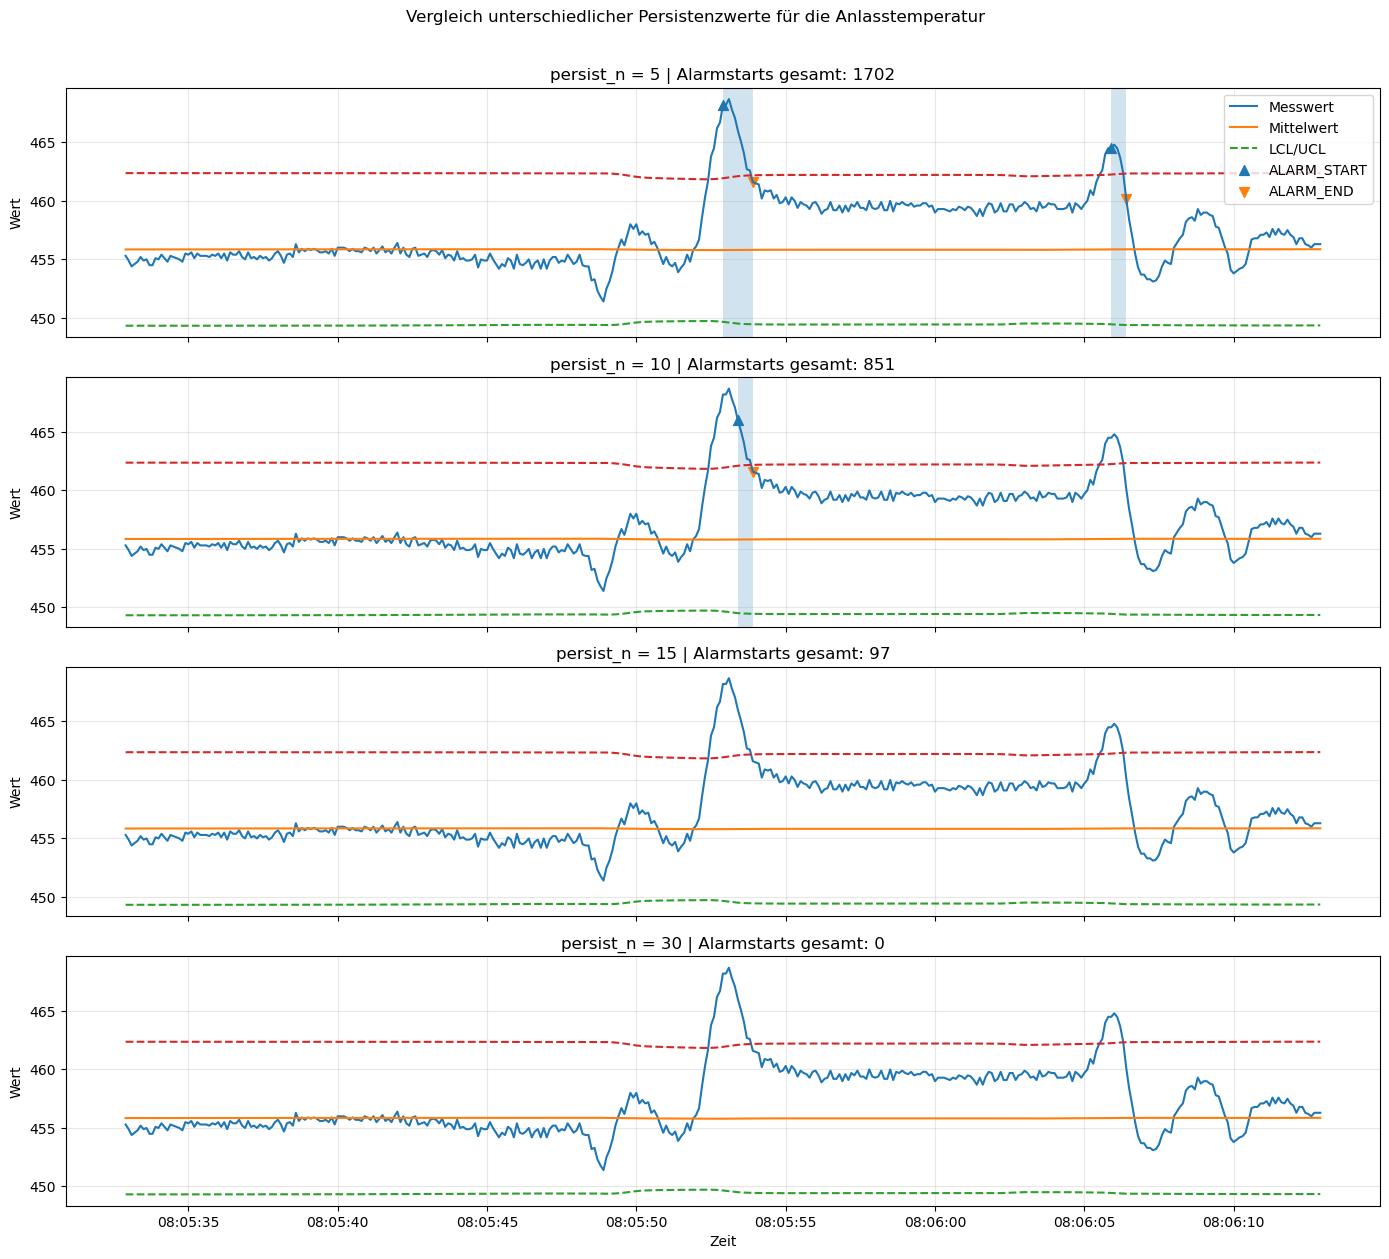

In [55]:
import pandas as pd
import numpy as np

def prepare_sixsigma_trace_fast(df, metric_col, window_n=3000):
    s = pd.to_numeric(df[metric_col], errors="coerce")

    mean = s.shift(1).rolling(window=window_n, min_periods=window_n).mean()
    std = s.shift(1).rolling(window=window_n, min_periods=window_n).std()

    lcl = mean - 3.0 * std
    ucl = mean + 3.0 * std

    violated = ((s < lcl) | (s > ucl)).fillna(False)

    trace = pd.DataFrame({
        "ts": df["Time"],
        "value": s,
        "mean": mean,
        "std": std,
        "lcl": lcl,
        "ucl": ucl,
        "violated": violated,
        "warmup": mean.isna(),
    })
    return trace

import matplotlib.pyplot as plt

def add_alarm_state(trace_df, persist_n=5):
    out = trace_df.copy()

    violated = out["violated"].to_numpy()
    event_type = np.array([""] * len(out), dtype=object)
    violation_run = np.zeros(len(out), dtype=int)
    in_alarm_arr = np.zeros(len(out), dtype=bool)

    in_alarm = False
    run_len = 0

    for i, is_viol in enumerate(violated):
        if is_viol:
            run_len += 1
        else:
            run_len = 0

        if (not in_alarm) and is_viol and run_len >= persist_n:
            in_alarm = True
            event_type[i] = "ALARM_START"

        elif in_alarm and (not is_viol):
            in_alarm = False
            event_type[i] = "ALARM_END"

        violation_run[i] = run_len
        in_alarm_arr[i] = in_alarm

    out["violation_run"] = violation_run
    out["in_alarm"] = in_alarm_arr
    out["event_type"] = event_type
    return out


def choose_window_around_first_alarm(trace_df, persist_n=5, pad_s=20):
    tmp = add_alarm_state(trace_df, persist_n=persist_n)
    starts = tmp.loc[tmp["event_type"] == "ALARM_START", "ts"]

    if starts.empty:
        # Fallback: erstes Stück nach Warm-up
        t0 = tmp.loc[~tmp["warmup"], "ts"].iloc[0]
        return t0, t0 + pd.Timedelta(seconds=60)

    t_alarm = starts.iloc[0]
    return t_alarm - pd.Timedelta(seconds=pad_s), t_alarm + pd.Timedelta(seconds=pad_s)


def _alarm_intervals(sub_df):
    intervals = []
    start_ts = None

    for _, row in sub_df.iterrows():
        if row["event_type"] == "ALARM_START":
            start_ts = row["ts"]
        elif row["event_type"] == "ALARM_END" and start_ts is not None:
            intervals.append((start_ts, row["ts"]))
            start_ts = None

    if start_ts is not None:
        intervals.append((start_ts, sub_df["ts"].iloc[-1]))

    return intervals


def plot_persistence_subplots(trace_df, persist_list=(5, 10, 15, 30), t_start=None, t_end=None, title=""):
    if t_start is None or t_end is None:
        t_start, t_end = choose_window_around_first_alarm(trace_df, persist_n=persist_list[0], pad_s=20)

    fig, axes = plt.subplots(len(persist_list), 1, figsize=(14, 3.2 * len(persist_list)), sharex=True)

    if len(persist_list) == 1:
        axes = [axes]

    for ax, p in zip(axes, persist_list):
        ann = add_alarm_state(trace_df, persist_n=p)
        sub = ann[(ann["ts"] >= t_start) & (ann["ts"] <= t_end)].copy()

        ax.plot(sub["ts"], sub["value"], label="Messwert")
        ax.plot(sub["ts"], sub["mean"], label="Mittelwert")
        ax.plot(sub["ts"], sub["lcl"], linestyle="--", label="LCL/UCL")
        ax.plot(sub["ts"], sub["ucl"], linestyle="--")

        # Alarmbereiche schattieren
        for a, b in _alarm_intervals(sub):
            ax.axvspan(a, b, alpha=0.2)

        # Start/Ende markieren
        starts = sub.loc[sub["event_type"] == "ALARM_START"]
        ends = sub.loc[sub["event_type"] == "ALARM_END"]

        if not starts.empty:
            ax.scatter(starts["ts"], starts["value"], marker="^", s=50, label="ALARM_START")
        if not ends.empty:
            ax.scatter(ends["ts"], ends["value"], marker="v", s=50, label="ALARM_END")

        n_start = int((ann["event_type"] == "ALARM_START").sum())
        ax.set_title("persist_n = {0} | Alarmstarts gesamt: {1}".format(p, n_start))
        ax.set_ylabel("Wert")
        ax.grid(True, alpha=0.3)

    axes[0].legend(loc="best")
    axes[-1].set_xlabel("Zeit")

    if title:
        fig.suptitle(title)
        fig.tight_layout(rect=[0, 0, 1, 0.97])
    else:
        fig.tight_layout()

    plt.show()
    
HARDT_KEY = "fHaertetemperatur (Haerten)"

hard_trace = prepare_sixsigma_trace_fast(df, HARDT_KEY, window_n=3000)

plot_persistence_subplots(
    hard_trace,
    persist_list=(5, 10, 15, 30),
    title="Vergleich unterschiedlicher Persistenzwerte für die Härtetemperatur"
)

TEMPT_KEY = "fAnlasstemperatur (Anlassen)"

temp_trace = prepare_sixsigma_trace_fast(df, TEMPT_KEY, window_n=3000)

plot_persistence_subplots(
    temp_trace,
    persist_list=(5, 10, 15, 30),
    title="Vergleich unterschiedlicher Persistenzwerte für die Anlasstemperatur"
)